# Hazard Index Model — Cabuyao, Laguna
## LSTM-based Time-Series Prediction for Hazard Assessment

**Methodology aligned with thesis reference paper (Chapter 3, Figures 5 & 8)**

### Pipeline Overview
| Phase | Description | Key Output |
|-------|-------------|------------|
| **Phase 1** | Data Loading & Preprocessing | Merged monthly hazard dataset (2020–2025) |
| **Phase 2** | Hazard Index Computation | Weighted normalized HI per barangay |
| **Phase 3** | LSTM Model Development | Trained LSTM for temporal prediction |
| **Phase 4** | Prediction & Forecasting | Hazard Index projections (2026–2030) |
| **Phase 5** | Interactive Visualization | Localhost choropleth map with year slider |

### Hazard Index Formula (from paper — Weighted Linear Combination)

$$HI = \sum_{i=1}^{n} w_i \cdot S_i'$$

Where:
- $S_i'$ = Min-max normalized spatial factor
- $w_i$ = AHP-derived weight for factor *i*

### AHP Weight Assignment
| Parameter | Weight |
|-----------|--------|
| Flood susceptibility | 0.25 |
| Landslide susceptibility | 0.20 |
| Earthquake magnitude/frequency | 0.20 |
| Typhoon severity/count | 0.20 |
| Rainfall intensity | 0.15 |

### Classification (Jenks — Five Susceptibility Zones)
| Category | Value Range |
|----------|-------------|
| Very Low | 0.0 – 0.2 |
| Low | 0.2 – 0.4 |
| Moderate | 0.4 – 0.6 |
| High | 0.6 – 0.8 |
| Very High | 0.8 – 1.0 |

In [1]:
# ============================================================
# Cell 1: Imports and Configuration
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
import json, os, sys, warnings
warnings.filterwarnings('ignore')

# --- Base Paths ---
BASE_PATH = Path(r'd:\Users\Vince Joseph\Downloads-New\Hazard')

# --- Barangay Bounding Boxes (from calamity_risk reference) ---
BARANGAY_BOUNDS = {
    'Baclaran':      {'lat_min': 14.240, 'lat_max': 14.250, 'lon_min': 121.160, 'lon_max': 121.175},
    'Banay-Banay':   {'lat_min': 14.250, 'lat_max': 14.260, 'lon_min': 121.125, 'lon_max': 121.140},
    'Banlic':        {'lat_min': 14.225, 'lat_max': 14.240, 'lon_min': 121.130, 'lon_max': 121.145},
    'Barangay Dos':  {'lat_min': 14.268, 'lat_max': 14.278, 'lon_min': 121.120, 'lon_max': 121.135},
    'Barangay Tres': {'lat_min': 14.275, 'lat_max': 14.285, 'lon_min': 121.115, 'lon_max': 121.130},
    'Barangay Uno':  {'lat_min': 14.270, 'lat_max': 14.280, 'lon_min': 121.130, 'lon_max': 121.145},
    'Bigaa':         {'lat_min': 14.285, 'lat_max': 14.295, 'lon_min': 121.125, 'lon_max': 121.140},
    'Butong':        {'lat_min': 14.285, 'lat_max': 14.295, 'lon_min': 121.130, 'lon_max': 121.145},
    'Casile':        {'lat_min': 14.160, 'lat_max': 14.175, 'lon_min': 121.015, 'lon_max': 121.030},
    'Diezmo':        {'lat_min': 14.225, 'lat_max': 14.240, 'lon_min': 121.085, 'lon_max': 121.100},
    'Gulod':         {'lat_min': 14.255, 'lat_max': 14.265, 'lon_min': 121.160, 'lon_max': 121.175},
    'Mamatid':       {'lat_min': 14.230, 'lat_max': 14.245, 'lon_min': 121.150, 'lon_max': 121.165},
    'Marinig':       {'lat_min': 14.265, 'lat_max': 14.280, 'lon_min': 121.145, 'lon_max': 121.165},
    'Niugan':        {'lat_min': 14.260, 'lat_max': 14.270, 'lon_min': 121.125, 'lon_max': 121.145},
    'Pittland':      {'lat_min': 14.225, 'lat_max': 14.240, 'lon_min': 121.100, 'lon_max': 121.115},
    'Pulo':          {'lat_min': 14.240, 'lat_max': 14.255, 'lon_min': 121.125, 'lon_max': 121.140},
    'Sala':          {'lat_min': 14.268, 'lat_max': 14.278, 'lon_min': 121.120, 'lon_max': 121.130},
    'San Isidro':    {'lat_min': 14.235, 'lat_max': 14.250, 'lon_min': 121.135, 'lon_max': 121.150}
}

BARANGAYS = list(BARANGAY_BOUNDS.keys())

# --- Hazard Index AHP Weights (from reference paper) ---
HAZARD_WEIGHTS = {
    'flood':      0.25,
    'landslide':  0.20,
    'earthquake': 0.20,
    'typhoon':    0.20,
    'rainfall':   0.15
}

# --- LSTM Configuration ---
SEQ_LENGTH     = 6      # 6-month lookback window
EPOCHS         = 120
BATCH_SIZE     = 16
LEARNING_RATE  = 0.001
TRAIN_SPLIT    = 0.80
PRED_YEARS     = list(range(2026, 2031))   # 2026-2030

print(f'Configuration loaded.')
print(f'Base Path:   {BASE_PATH}')
print(f'Barangays:   {len(BARANGAYS)}')
print(f'HI Weights:  {HAZARD_WEIGHTS}')
print(f'LSTM Window: {SEQ_LENGTH} months')
print(f'Prediction:  {PRED_YEARS[0]}-{PRED_YEARS[-1]}')

Configuration loaded.
Base Path:   d:\Users\Vince Joseph\Downloads-New\Hazard
Barangays:   18
HI Weights:  {'flood': 0.25, 'landslide': 0.2, 'earthquake': 0.2, 'typhoon': 0.2, 'rainfall': 0.15}
LSTM Window: 6 months
Prediction:  2026-2030


## Phase 1 — Data Loading & Preprocessing

Load all hazard-related datasets:
- **Flood susceptibility** (spatial point data from HazardHunterPH)
- **Landslide susceptibility** (slope/elevation from HazardHunterPH)
- **Weather** — rainfall, temperature, humidity (Open-Meteo, monthly 2020–2025)
- **Earthquake** frequency and magnitude (PHIVOLCS, monthly)
- **Typhoon** frequency and severity (PAGASA, monthly)
- **Population** per barangay (PSA, monthly interpolated)
- **Infrastructure** count per barangay (OpenStreetMap)

In [2]:
# ============================================================
# Cell 2: Load Raw Data & Aggregate to Barangay-Monthly Level
# ============================================================

# ---------- helper: assign point to barangay ----------
def assign_barangay(lat, lon):
    for brgy, b in BARANGAY_BOUNDS.items():
        if b['lat_min'] <= lat <= b['lat_max'] and b['lon_min'] <= lon <= b['lon_max']:
            return brgy
    return None

def aggregate_to_barangay(df, lat_col, lon_col, value_col, agg='mean'):
    df = df.copy()
    df['barangay'] = df.apply(lambda r: assign_barangay(r[lat_col], r[lon_col]), axis=1)
    grp = df[df['barangay'].notna()].groupby('barangay')[value_col]
    agg_map = {'mean': grp.mean, 'max': grp.max, 'sum': grp.sum, 'count': grp.count}
    aggregated = agg_map[agg]()
    return pd.Series({b: aggregated.get(b, 0.0) for b in BARANGAYS}, dtype=float)

# ---------- 1. Flood susceptibility (static per barangay) ----------
flood_df = pd.read_csv(BASE_PATH / 'flood_susceptibility.csv')
flood_by_brgy = aggregate_to_barangay(flood_df, 'latitude', 'longitude', 'flood_recurrence_pct')
print(f'Flood Susceptibility loaded: {flood_df.shape}')

# ---------- 2. Landslide susceptibility (static per barangay) ----------
landslide_df = pd.read_csv(BASE_PATH / 'landslide_susceptibility.csv')
landslide_by_brgy = aggregate_to_barangay(landslide_df, 'latitude', 'longitude', 'slope_degrees')
print(f'Landslide Susceptibility loaded: {landslide_df.shape}')

# ---------- 3. Infrastructure count (static per barangay) ----------
infra_df = pd.read_csv(BASE_PATH / 'infrastructure.csv')
infra_df['barangay'] = infra_df.apply(lambda r: assign_barangay(r['latitude'], r['longitude']), axis=1)
infra_counts = infra_df[infra_df['barangay'].notna()].groupby('barangay').size()
infra_by_brgy = {b: int(infra_counts.get(b, 0)) for b in BARANGAYS}
print(f'Infrastructure loaded: {infra_df.shape}')

# ---------- 4. Weather data (monthly, broadcast to all barangays) ----------
weather_df = pd.read_csv(BASE_PATH / 'weather_data.csv')
weather_df['date'] = pd.to_datetime(weather_df['date']).dt.tz_localize(None)
weather_df['date'] = weather_df['date'].dt.to_period('M').dt.to_timestamp()
weather_df = weather_df.rename(columns={
    'Temperature (°C)': 'temp', 'Humidity (%)': 'humidity', 'Rainfall (mm)': 'rainfall'
})
print(f'Weather loaded: {weather_df.shape}  |  {weather_df["date"].min().date()} → {weather_df["date"].max().date()}')

# ---------- 5. Earthquake data (monthly, broadcast) ----------
earthquake_df = pd.read_csv(BASE_PATH / 'earthquake_freq.csv')
earthquake_df['date'] = pd.to_datetime(earthquake_df['date'])
earthquake_df = earthquake_df.rename(columns={'max_magnitude': 'earthquake_mag', 'quake_count': 'earthquake_count'})
print(f'Earthquake loaded: {earthquake_df.shape}')

# ---------- 6. Typhoon data (monthly, broadcast) ----------
typhoon_df = pd.read_csv(BASE_PATH / 'typhoon_freq.csv')
typhoon_df['date'] = pd.to_datetime(typhoon_df['date'])
typhoon_df = typhoon_df.rename(columns={'max_severity': 'typhoon_severity'})
print(f'Typhoon loaded: {typhoon_df.shape}')

# ---------- 7. Population data (per barangay, monthly) ----------
population_df = pd.read_csv(BASE_PATH / 'population_barangay.csv')
population_df['Date'] = pd.to_datetime(population_df['Date'])
pop_cols = [c for c in population_df.columns if c not in ['Date', 'Total_Cabuyao']]
population_long = population_df.melt(id_vars=['Date'], value_vars=pop_cols,
                                      var_name='barangay', value_name='population')
population_long = population_long.rename(columns={'Date': 'date'})
print(f'Population loaded: {population_long.shape}')

# ---------- 8. Build merged monthly dataset (May 2020 – Dec 2025) ----------
date_range = sorted(weather_df[weather_df['date'] >= '2020-05-01']['date'].unique())
base_records = [{'date': d, 'barangay': b} for d in date_range for b in BARANGAYS]
merged = pd.DataFrame(base_records)
merged['date'] = pd.to_datetime(merged['date'])

# merge weather (broadcast)
merged = merged.merge(weather_df[['date', 'temp', 'humidity', 'rainfall']], on='date', how='left')

# merge population
merged = merged.merge(population_long[['date', 'barangay', 'population']], on=['date', 'barangay'], how='left')

# merge static susceptibility
susc = pd.DataFrame({'barangay': BARANGAYS,
                      'flood_susceptibility': [flood_by_brgy[b] for b in BARANGAYS],
                      'landslide_susceptibility': [landslide_by_brgy[b] for b in BARANGAYS],
                      'infra_count': [infra_by_brgy[b] for b in BARANGAYS]})
merged = merged.merge(susc, on='barangay', how='left')

# merge earthquake (broadcast)
merged = merged.merge(earthquake_df[['date', 'earthquake_mag', 'earthquake_count']], on='date', how='left')

# merge typhoon (broadcast)
merged = merged.merge(typhoon_df[['date', 'typhoon_severity', 'typhoon_count']], on='date', how='left')

# fill missing
merged = merged.fillna(0)

print(f'\n=== Merged Dataset ===')
print(f'Shape: {merged.shape}')
print(f'Date range: {merged["date"].min().date()} → {merged["date"].max().date()}')
print(f'Months: {merged["date"].nunique()}  |  Barangays: {merged["barangay"].nunique()}')
print(f'Columns: {list(merged.columns)}')

Flood Susceptibility loaded: (2000, 3)
Landslide Susceptibility loaded: (1999, 4)
Infrastructure loaded: (82, 5)
Weather loaded: (72, 4)  |  2020-01-01 → 2025-12-01
Earthquake loaded: (72, 4)
Typhoon loaded: (72, 3)
Population loaded: (1224, 3)

=== Merged Dataset ===
Shape: (1224, 13)
Date range: 2020-05-01 → 2025-12-01
Months: 68  |  Barangays: 18
Columns: ['date', 'barangay', 'temp', 'humidity', 'rainfall', 'population', 'flood_susceptibility', 'landslide_susceptibility', 'infra_count', 'earthquake_mag', 'earthquake_count', 'typhoon_severity', 'typhoon_count']


## Phase 2 — Hazard Index Computation

Following the reference paper methodology (Figure 8):
1. **Min-max normalize** each spatial layer to [0, 1]
2. **AHP weight assignment** (flood 0.25, landslide 0.20, earthquake 0.20, typhoon 0.20, rainfall 0.15)
3. **Weighted Linear Combination** (WLC): $HI = \sum w_i \cdot S_i'$
4. **Jenks classification** into five susceptibility zones

=== Hazard Index Statistics ===
       hazard_index  hazard_index_100
count     1224.0000         1224.0000
mean         0.3878           38.7773
std          0.0822            8.2157
min          0.2000           20.0000
25%          0.3453           34.5281
50%          0.3926           39.2643
75%          0.4381           43.8145
max          0.6331           63.3141

=== Hazard Classification Distribution ===
hazard_class
High          3
Low         652
Moderate    569
Name: count, dtype: int64

=== Annual Hazard Index (sample — Butong, highest flood risk) ===
 year barangay  hazard_index_100
 2020   Butong         57.219550
 2021   Butong         52.626626
 2022   Butong         53.781405
 2023   Butong         52.572177
 2024   Butong         53.866820
 2025   Butong         53.941913


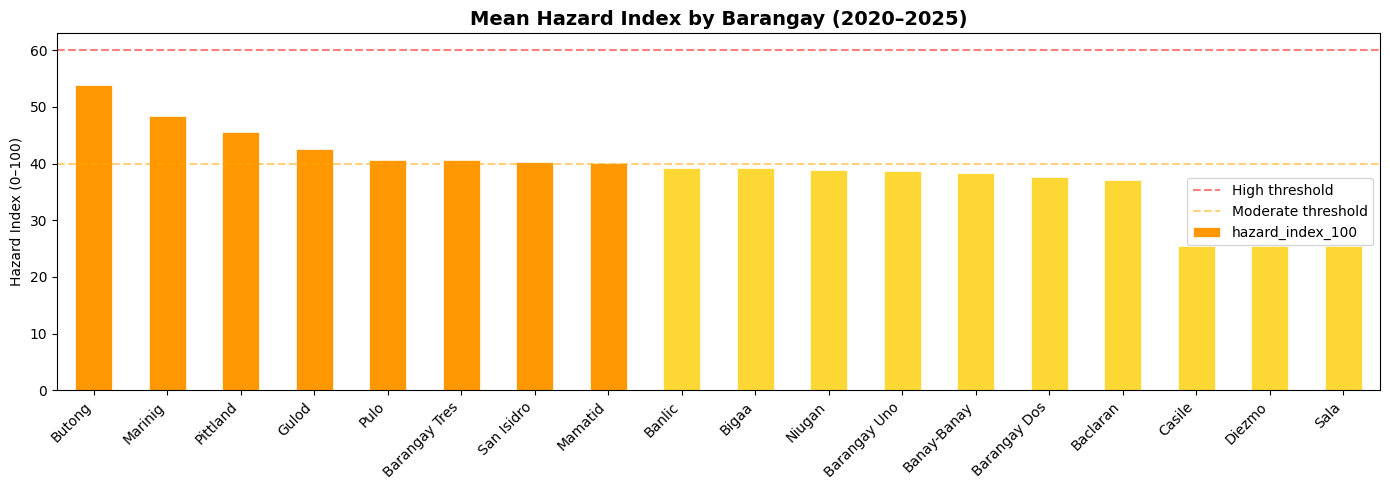

In [3]:
# ============================================================
# Cell 3: Compute Hazard Index (Weighted Linear Combination)
# ============================================================
import matplotlib.pyplot as plt

def minmax_norm(s):
    """Min-max normalize a Series to [0, 1]."""
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn) if mx != mn else pd.Series(0.5, index=s.index)

# --- Normalize each hazard factor globally ---
merged['flood_norm']      = minmax_norm(merged['flood_susceptibility'])
merged['landslide_norm']  = minmax_norm(merged['landslide_susceptibility'])
merged['earthquake_norm'] = minmax_norm(merged['earthquake_mag'].replace(0, 0.01))
merged['typhoon_norm']    = minmax_norm(merged['typhoon_severity'].replace(0, 0.01))
merged['rainfall_norm']   = minmax_norm(merged['rainfall'])

# --- Weighted Linear Combination (WLC) → Hazard Index [0, 1] ---
merged['hazard_index'] = (
    HAZARD_WEIGHTS['flood']      * merged['flood_norm'] +
    HAZARD_WEIGHTS['landslide']  * merged['landslide_norm'] +
    HAZARD_WEIGHTS['earthquake'] * merged['earthquake_norm'] +
    HAZARD_WEIGHTS['typhoon']    * merged['typhoon_norm'] +
    HAZARD_WEIGHTS['rainfall']   * merged['rainfall_norm']
)

# --- Jenks Classification (five susceptibility zones from paper Table 2) ---
def classify_hazard(hi):
    if hi >= 0.8: return 'Very High'
    if hi >= 0.6: return 'High'
    if hi >= 0.4: return 'Moderate'
    if hi >= 0.2: return 'Low'
    return 'Very Low'

merged['hazard_class'] = merged['hazard_index'].apply(classify_hazard)

# --- Also compute the hazard_index scaled to 0-100 for visualization ---
merged['hazard_index_100'] = merged['hazard_index'] * 100

# --- Summary ---
print('=== Hazard Index Statistics ===')
print(merged[['hazard_index', 'hazard_index_100']].describe().round(4))
print(f'\n=== Hazard Classification Distribution ===')
print(merged['hazard_class'].value_counts().sort_index())

# --- Annual mean per barangay (for visualization reference) ---
merged['year'] = merged['date'].dt.year
annual_hi = merged.groupby(['year', 'barangay'])['hazard_index_100'].mean().reset_index()
print(f'\n=== Annual Hazard Index (sample — Butong, highest flood risk) ===')
print(annual_hi[annual_hi['barangay'] == 'Butong'].to_string(index=False))

# --- Quick bar chart: Mean HI per barangay ---
fig, ax = plt.subplots(figsize=(14, 5))
brgy_mean = merged.groupby('barangay')['hazard_index_100'].mean().sort_values(ascending=False)
colors = ['#d32f2f' if v >= 60 else '#ff9800' if v >= 40 else '#fdd835' if v >= 20 else '#66bb6a' for v in brgy_mean]
brgy_mean.plot(kind='bar', ax=ax, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Mean Hazard Index by Barangay (2020–2025)', fontsize=14, fontweight='bold')
ax.set_ylabel('Hazard Index (0–100)')
ax.set_xlabel('')
ax.axhline(y=60, color='red', linestyle='--', alpha=0.5, label='High threshold')
ax.axhline(y=40, color='orange', linestyle='--', alpha=0.5, label='Moderate threshold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Phase 3 — LSTM Model Development

Using a Long Short-Term Memory (LSTM) network to learn temporal hazard patterns and
predict future Hazard Index values per barangay.

**Architecture** (aligned with reference paper Figure 6):
- Input: 6-month sliding window of hazard features per barangay
- Features: rainfall, temperature, humidity, earthquake magnitude/count, typhoon severity/count, flood susceptibility, landslide susceptibility
- Hidden: 2-layer LSTM (64 → 32 units) + Dense head
- Output: predicted Hazard Index (single value)
- Training: 80/20 temporal split, all 18 barangays combined

In [4]:
# ============================================================
# Cell 4: Prepare LSTM Sequences
# ============================================================
from sklearn.preprocessing import MinMaxScaler
import joblib

# --- Select features for LSTM input ---
FEATURE_COLS = [
    'rainfall', 'temp', 'humidity',
    'earthquake_mag', 'earthquake_count',
    'typhoon_severity', 'typhoon_count',
    'flood_susceptibility', 'landslide_susceptibility'
]
TARGET_COL = 'hazard_index'

# --- Sort data by barangay and date ---
merged_sorted = merged.sort_values(['barangay', 'date']).reset_index(drop=True)

# --- Fit scalers on entire training range ---
feature_scaler = MinMaxScaler()
target_scaler  = MinMaxScaler()

X_all = merged_sorted[FEATURE_COLS].values
y_all = merged_sorted[[TARGET_COL]].values

feature_scaler.fit(X_all)
target_scaler.fit(y_all)

X_scaled = feature_scaler.transform(X_all)
y_scaled = target_scaler.transform(y_all).flatten()

merged_sorted['y_scaled'] = y_scaled
for i, col in enumerate(FEATURE_COLS):
    merged_sorted[f'{col}_scaled'] = X_scaled[:, i]

scaled_feat_cols = [f'{c}_scaled' for c in FEATURE_COLS]

# --- Create sliding-window sequences per barangay ---
def create_sequences(df, feat_cols, target_col, seq_len):
    """Create (X, y) pairs using a sliding window per barangay."""
    Xs, ys, meta = [], [], []
    for brgy in BARANGAYS:
        brgy_df = df[df['barangay'] == brgy].sort_values('date').reset_index(drop=True)
        feats = brgy_df[feat_cols].values
        targets = brgy_df[target_col].values
        dates = brgy_df['date'].values
        for i in range(len(brgy_df) - seq_len):
            Xs.append(feats[i:i+seq_len])
            ys.append(targets[i+seq_len])
            meta.append({'barangay': brgy, 'pred_date': dates[i+seq_len]})
    return np.array(Xs), np.array(ys), meta

X_seq, y_seq, seq_meta = create_sequences(
    merged_sorted, scaled_feat_cols, 'y_scaled', SEQ_LENGTH
)

print(f'=== LSTM Sequences ===')
print(f'X shape: {X_seq.shape}  →  (samples, timesteps={SEQ_LENGTH}, features={len(FEATURE_COLS)})')
print(f'y shape: {y_seq.shape}')

# --- Temporal train/test split (80/20 by time) ---
n_total = len(X_seq)
n_train = int(n_total * TRAIN_SPLIT)

X_train, X_test = X_seq[:n_train], X_seq[n_train:]
y_train, y_test = y_seq[:n_train], y_seq[n_train:]
meta_train, meta_test = seq_meta[:n_train], seq_meta[n_train:]

print(f'Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples')

# --- Save scalers for the visualization server ---
os.makedirs(BASE_PATH / 'model_artifacts', exist_ok=True)
joblib.dump(feature_scaler, BASE_PATH / 'model_artifacts' / 'hi_feature_scaler.joblib')
joblib.dump(target_scaler,  BASE_PATH / 'model_artifacts' / 'hi_target_scaler.joblib')
print('Scalers saved to model_artifacts/')

=== LSTM Sequences ===
X shape: (1116, 6, 9)  →  (samples, timesteps=6, features=9)
y shape: (1116,)
Train: 892 samples  |  Test: 224 samples
Scalers saved to model_artifacts/


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 6, 64)          │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,905 (124.63 KB)

 Trainable params: 31,905 (124.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/120
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0289 - mae: 0.1295 - val_loss: 0.0208 - val_mae: 0.1136 - learning_rate: 0.0010
Epoch 2/120
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0087 - mae: 0.0739 - val_loss: 0.0063 - val_mae: 0.0660 - learning_rate: 0.0010
Epoch 3/120
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0064 - mae: 0.0628 - val_loss: 0.0059 - val_mae: 0.0644 - learning_rate: 0.0010
Epoch 4/120
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0061 - mae: 0.0619 - val_loss: 0.0054 - val_mae: 0.0611 - learning_rate: 0.0010
Epoch 5/120
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0053 - mae: 0.0581 - val_loss: 0.0047 - val_mae: 0.0565 - learning_rate: 0.0010
Epoch 6/120
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0054 - mae: 0.0580 - val_loss: 0.0044 - val_mae: 0.0525 - learning_rate: 0.0010
Epoch 7/120
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0048 - mae: 0.0542 - val_loss: 0.0042 - val_mae: 0.0528 - learning_rate: 0.0010
Epoch 

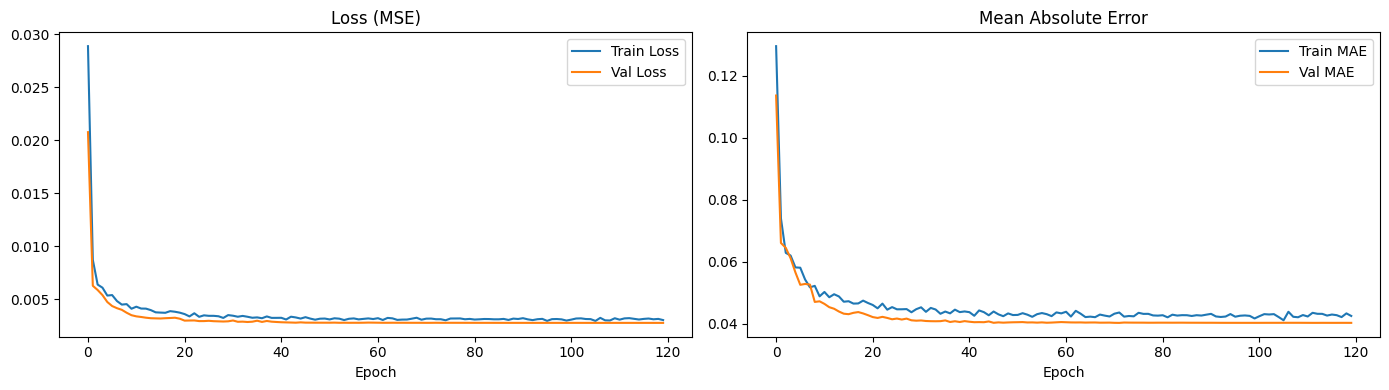


Model saved: model_artifacts/lstm_hazard_index.keras


In [5]:
# ============================================================
# Cell 5: Build and Train LSTM Model
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)
np.random.seed(42)

n_features = X_train.shape[2]

# --- Build LSTM Architecture (aligned with reference paper Figure 6) ---
model = Sequential([
    Input(shape=(SEQ_LENGTH, n_features)),
    LSTM(64, return_sequences=True, activation='tanh'),
    Dropout(0.2),
    LSTM(32, return_sequences=False, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')        # output [0,1] for normalized HI
])

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mse',
    metrics=['mae']
)

model.summary()

# --- Callbacks ---
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)
]

# --- Train ---
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

# --- Plot training curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss (MSE)')
axes[0].legend()
axes[0].set_xlabel('Epoch')

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('Mean Absolute Error')
axes[1].legend()
axes[1].set_xlabel('Epoch')
plt.tight_layout()
plt.show()

# --- Save model ---
model.save(BASE_PATH / 'model_artifacts' / 'lstm_hazard_index.keras')
print('\nModel saved: model_artifacts/lstm_hazard_index.keras')

  LSTM Hazard Index — Evaluation Metrics
  RMSE  (Root Mean Square Error)  : 0.022793
  MAE   (Mean Absolute Error)     : 0.017416
  R²    (Coefficient of Determ.)  : 0.9266
  NMAE  (Normalized MAE)          : 0.0514

  95% CI of prediction error: [-0.002799, 0.003171]
  Mean error:  0.000186
  Margin:      ±0.002985


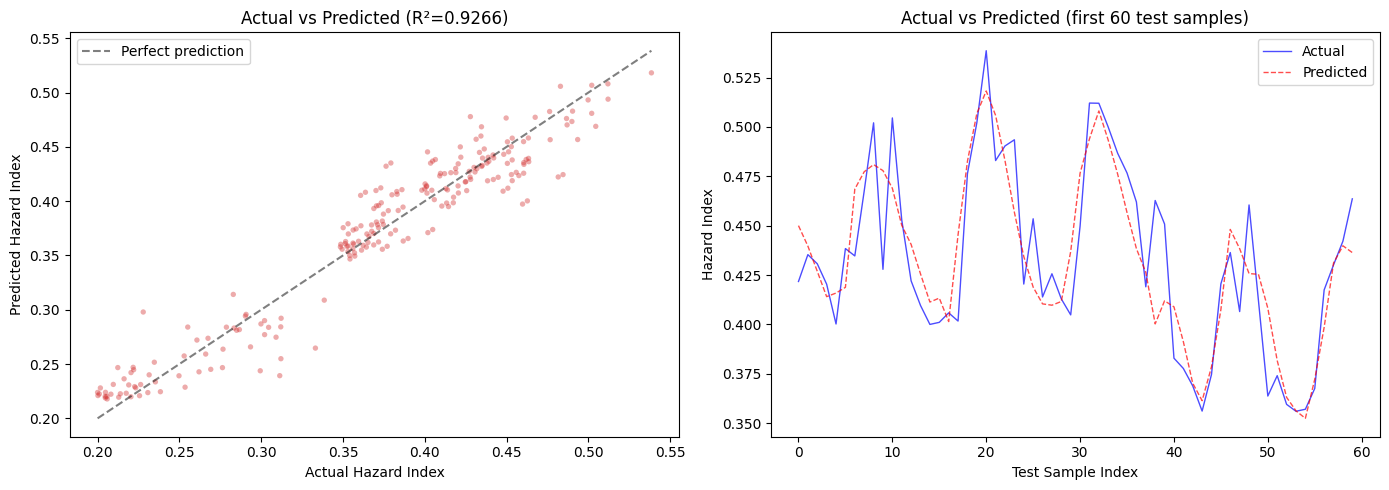

In [6]:
# ============================================================
# Cell 6: Model Evaluation (RMSE, MAE, R², NMAE — per paper)
# ============================================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Predict on test set (inverse-transform to original scale) ---
y_pred_scaled = model.predict(X_test, verbose=0).flatten()
y_pred = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# --- Metrics (aligned with reference paper Section: Model Validation) ---
rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
mae   = mean_absolute_error(y_true, y_pred)
r2    = r2_score(y_true, y_pred)
nmae  = mae / (y_true.max() - y_true.min()) if (y_true.max() - y_true.min()) > 0 else 0.0

print('=' * 50)
print('  LSTM Hazard Index — Evaluation Metrics')
print('=' * 50)
print(f'  RMSE  (Root Mean Square Error)  : {rmse:.6f}')
print(f'  MAE   (Mean Absolute Error)     : {mae:.6f}')
print(f'  R²    (Coefficient of Determ.)  : {r2:.4f}')
print(f'  NMAE  (Normalized MAE)          : {nmae:.4f}')
print('=' * 50)

# --- 95% Confidence Interval (per paper) ---
errors = y_true - y_pred
ci_mean = np.mean(errors)
ci_std  = np.std(errors)
ci_n    = len(errors)
z_95    = 1.96
margin  = z_95 * (ci_std / np.sqrt(ci_n))
print(f'\n  95% CI of prediction error: [{ci_mean - margin:.6f}, {ci_mean + margin:.6f}]')
print(f'  Mean error:  {ci_mean:.6f}')
print(f'  Margin:      ±{margin:.6f}')

# --- Scatter plot: Actual vs Predicted ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(y_true, y_pred, alpha=0.4, s=15, c='#d32f2f', edgecolors='none')
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
axes[0].plot(lims, lims, 'k--', alpha=0.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Hazard Index')
axes[0].set_ylabel('Predicted Hazard Index')
axes[0].set_title(f'Actual vs Predicted (R²={r2:.4f})')
axes[0].legend()

# Time series comparison (first few test barangays)
test_dates = [m['pred_date'] for m in meta_test]
axes[1].plot(range(len(y_true[:60])), y_true[:60], 'b-', alpha=0.7, label='Actual', linewidth=1)
axes[1].plot(range(len(y_pred[:60])), y_pred[:60], 'r--', alpha=0.7, label='Predicted', linewidth=1)
axes[1].set_xlabel('Test Sample Index')
axes[1].set_ylabel('Hazard Index')
axes[1].set_title('Actual vs Predicted (first 60 test samples)')
axes[1].legend()

plt.tight_layout()
plt.show()

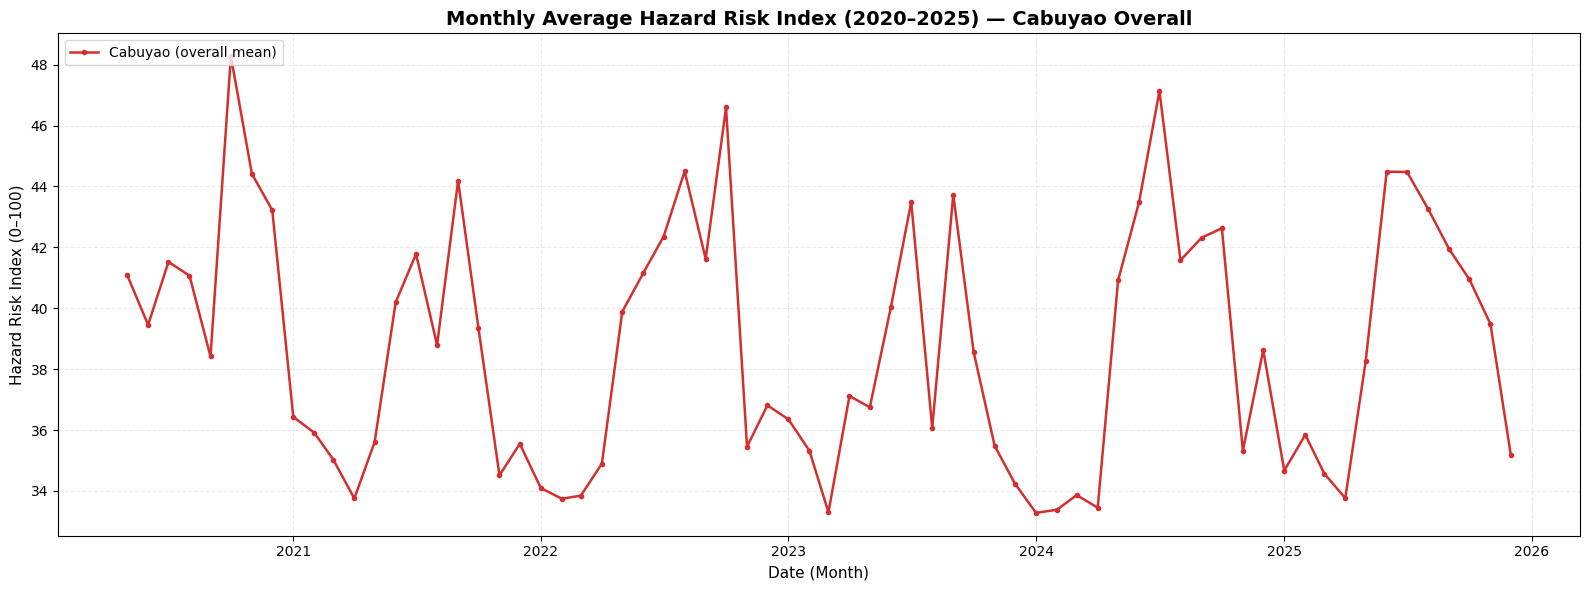

In [7]:
# Cell X: Line Chart — Monthly Average Hazard Risk Index (2020–2025) by Barangay
# ==============================================================================
# Uses the merged monthly hazard dataset with computed hazard_index_100.
# Plots a multi-line chart: each barangay as a separate line, 2020–2025.

import matplotlib.pyplot as plt

# Ensure date column is datetime
merged['date'] = pd.to_datetime(merged['date'])

# Filter for 2020–2025 just in case
mask = (merged['date'].dt.year >= 2020) & (merged['date'].dt.year <= 2025)
plot_df = merged.copy()

# 1) Compute monthly average hazard index over ALL barangays (Cabuyao overall)
monthly_hi_overall = (
    plot_df
    .groupby('date')['hazard_index_100']
    .mean()
    .reset_index()
)

# 2) Plot a single line for Cabuyao (overall)
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    monthly_hi_overall['date'],
    monthly_hi_overall['hazard_index_100'],
    marker='o',
    markersize=3,
    linewidth=1.8,
    color='#d32f2f',
    label='Cabuyao (overall mean)'
)

ax.set_title('Monthly Average Hazard Risk Index (2020–2025) — Cabuyao Overall',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date (Month)', fontsize=11)
ax.set_ylabel('Hazard Risk Index (0–100)', fontsize=11)

ax.grid(True, which='both', linestyle='--', alpha=0.25)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [8]:
# Cell Z: Preview 6 Barangays — Max Hazard Index per Barangay (with source factors)
# ================================================================================
# For visualization in the paper, show 6 different barangays. For each barangay,
# take the month with the highest hazard_index_100 and pull population and
# event-based factors from the original CSVs using month-level joins.

# Base columns from merged
base_cols = [
    'date', 'barangay',
    'rainfall', 'temp', 'humidity',
    'flood_susceptibility', 'landslide_susceptibility',
    'hazard_index_100'
]

# One highest-hazard record per barangay (using merged)
idx = merged.groupby('barangay')['hazard_index_100'].idxmax()
per_brgy_top = merged.loc[idx, base_cols].reset_index(drop=True)

# Normalize date to month key
per_brgy_top['month'] = per_brgy_top['date'].dt.to_period('M').dt.to_timestamp()

# --- Population from CSV (per barangay) ---
pop_df = pd.read_csv(BASE_PATH / 'population_barangay.csv')
pop_df['Date'] = pd.to_datetime(pop_df['Date']).dt.to_period('M').dt.to_timestamp()
pop_cols = [c for c in pop_df.columns if c not in ['Date', 'Total_Cabuyao']]
pop_long = pop_df.melt(id_vars=['Date'], value_vars=pop_cols,
                        var_name='barangay', value_name='population')
pop_long = pop_long.rename(columns={'Date': 'month'})

per_brgy_top = per_brgy_top.merge(
    pop_long[['month', 'barangay', 'population']],
    on=['month', 'barangay'],
    how='left'
)

# --- Earthquake from CSV (broadcast to all barangays) ---
eq_df = pd.read_csv(BASE_PATH / 'earthquake_freq.csv')
eq_df['date'] = pd.to_datetime(eq_df['date']).dt.to_period('M').dt.to_timestamp()
eq_df = eq_df.rename(columns={'max_magnitude': 'earthquake_mag', 'quake_count': 'earthquake_count'})
eq_df = eq_df.rename(columns={'date': 'month'})

per_brgy_top = per_brgy_top.merge(
    eq_df[['month', 'earthquake_mag', 'earthquake_count']],
    on='month',
    how='left'
)

# --- Typhoon from CSV (broadcast to all barangays) ---
ty_df = pd.read_csv(BASE_PATH / 'typhoon_freq.csv')
ty_df['date'] = pd.to_datetime(ty_df['date']).dt.to_period('M').dt.to_timestamp()
ty_df = ty_df.rename(columns={'max_severity': 'typhoon_severity'})
ty_df = ty_df.rename(columns={'date': 'month'})

per_brgy_top = per_brgy_top.merge(
    ty_df[['month', 'typhoon_severity', 'typhoon_count']],
    on='month',
    how='left'
)

# Final selection: 6 distinct barangays (sorted, with non-zero flood)
# Only keep barangays where flood_susceptibility > 0 so the table
# shows meaningful flood values for the paper.
per_brgy_top_nz = per_brgy_top[per_brgy_top['flood_susceptibility'] > 0]

Top6_hazard_index_distinct = (
    per_brgy_top_nz
    .sort_values('hazard_index_100', ascending=False)      # true top-6 by score
    .head(6)
    .assign(year=lambda df: df['date'].dt.year)           # extract year
    [[
        'year',                                           # show year first
        'date', 'barangay', 'population',
        'rainfall', 'temp', 'humidity',
        'flood_susceptibility', 'landslide_susceptibility',
        'hazard_index_100'
    ]]
    .reset_index(drop=True)
)

display(Top6_hazard_index_distinct)

,year,date,barangay,population,rainfall,temp,humidity,flood_susceptibility,landslide_susceptibility,hazard_index_100
0,2020,2020-10-01,Butong,14732,491.2,26.581451,87.98211,64.428571,0.624417,63.314075
1,2020,2020-10-01,Marinig,47284,491.2,26.581451,87.98211,39.410256,1.441840,57.944756
2,2020,2020-10-01,Gulod,17694,491.2,26.581451,87.98211,25.704545,1.356382,52.173008
3,2020,2020-10-01,Niugan,36941,491.2,26.581451,87.98211,0.814815,2.465074,48.399480
4,2020,2020-10-01,Baclaran,14581,491.2,26.581451,87.98211,1.562500,2.087027,46.683127


,Year,Barangay,Hazard_Index,hazard_class
0,2020,Butong,57.219550,Moderate
1,2020,Marinig,51.850232,Moderate
2,2020,Pittland,48.905476,Moderate
3,2020,Gulod,46.078484,Moderate
4,2020,Pulo,44.044175,Moderate
5,2020,Barangay Tres,43.988420,Moderate
6,2020,San Isidro,43.749716,Moderate
7,2020,Mamatid,43.434060,Moderate
8,2020,Banlic,42.709445,Moderate
9,2020,Bigaa,42.705283,Moderate


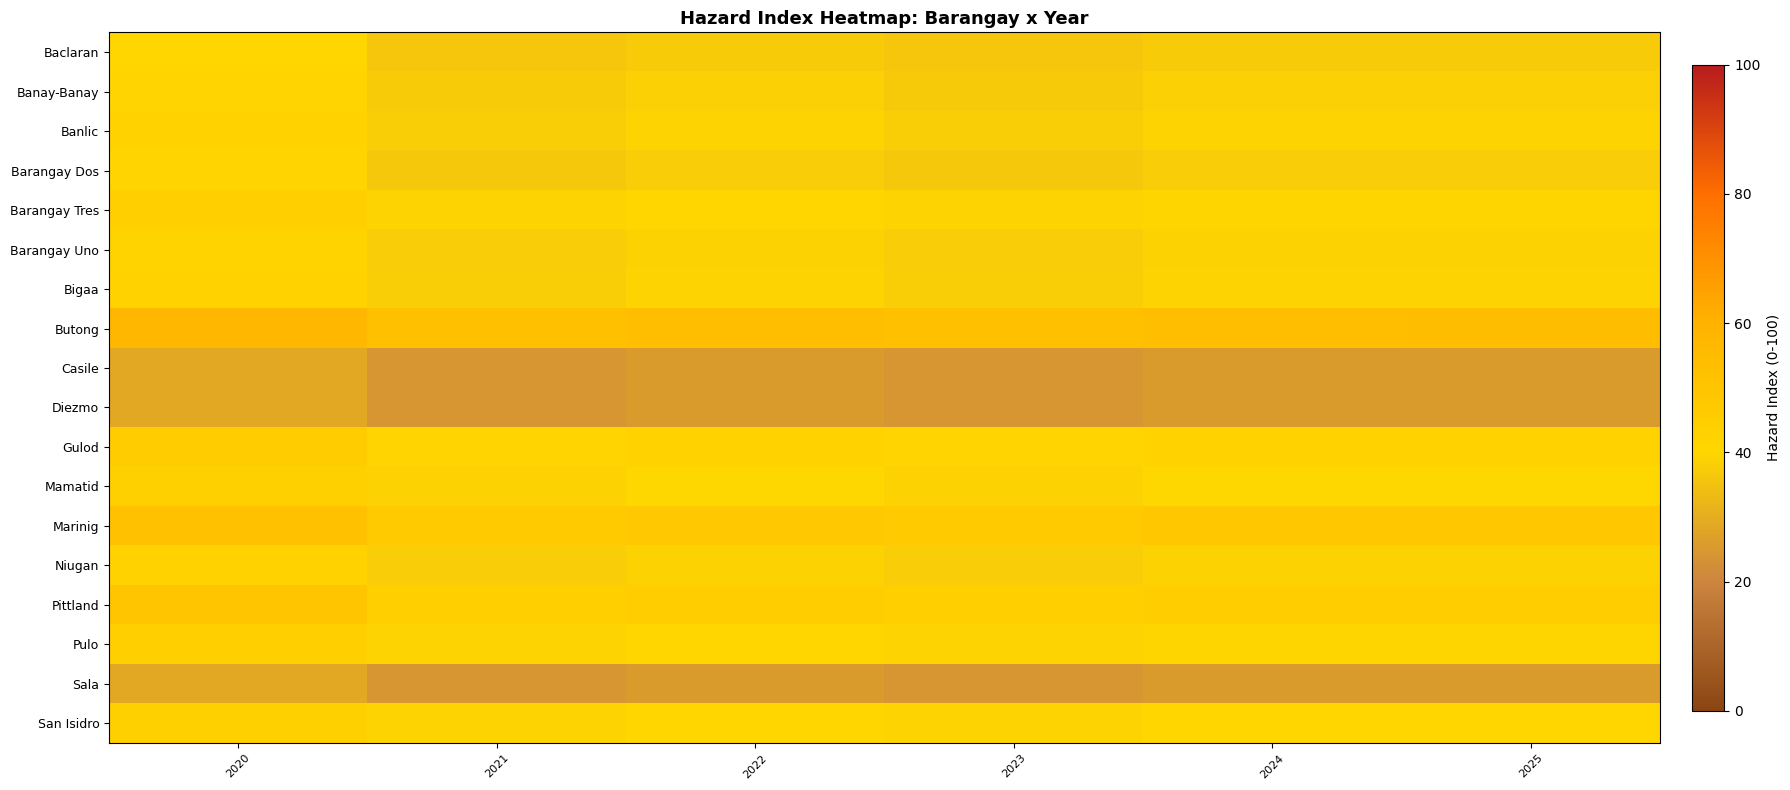

In [9]:
# Cell AA: Barangay-level Hazard Index Summary by Year + Heatmap
# ==================================================================
# 1) Table: average annual Hazard Index per barangay for a selected year
# 2) Heatmap: Hazard Index (0–100) by Barangay x Year (similar to Green Index)

import matplotlib.colors as mcolors

# --- 1) Tabular summary for a chosen year ---
summary_year = 2020  # <-- change this year as needed

# Ensure annual_hi exists (can re-run even if Cell 3 wasn't run in this session)
if 'annual_hi' not in globals():
    annual_hi = (
        merged
        .groupby(['year', 'barangay'])['hazard_index_100']
        .mean()
        .reset_index()
    )

hi_year = annual_hi[annual_hi['year'] == summary_year].copy()

# Add classification using the same Jenks-style thresholds
hi_year['hazard_class'] = hi_year['hazard_index_100'].div(100.0).apply(classify_hazard)

# Sort by hazard_index_100 (descending) for readability
hi_year = hi_year.sort_values('hazard_index_100', ascending=False)

# Rename columns for paper-friendly labels
hi_year = hi_year.rename(columns={
    'year': 'Year',
    'barangay': 'Barangay',
    'hazard_index_100': 'Hazard_Index'
})

display(hi_year.reset_index(drop=True))

# --- 2) Heatmap: Hazard Index by barangay and year (Barangay x Year) ---
fig, ax = plt.subplots(figsize=(18, 8))

pivot_hi = annual_hi.pivot(index='barangay', columns='year', values='hazard_index_100')

# Use a similar warm-to-green colormap as the Green Index heatmap
cmap_heat = mcolors.LinearSegmentedColormap.from_list(
    'hi_heat', ['#8B4513', '#CD853F', '#FFD700', '#FFB300', '#FF6F00', '#B71C1C']
)

im = ax.imshow(pivot_hi.values, cmap=cmap_heat, aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(len(pivot_hi.columns)))
ax.set_xticklabels(pivot_hi.columns, rotation=45, fontsize=8)
ax.set_yticks(range(len(pivot_hi.index)))
ax.set_yticklabels(pivot_hi.index, fontsize=9)
plt.colorbar(im, ax=ax, label='Hazard Index (0-100)', fraction=0.02, pad=0.02)
ax.set_title('Hazard Index Heatmap: Barangay x Year', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Cell AB: Barangay-level Hazard Index summary by selected years (city-wide)
# ========================================================================
# Summarize barangay-level Hazard Index statistics (mean, min, max) for
# selected years, similar to the Green Index summary table.

# Ensure annual_hi exists (can re-run even if Cell 3 wasn't run in this session)
if 'annual_hi' not in globals():
    annual_hi = (
        merged
        .groupby(['year', 'barangay'])['hazard_index_100']
        .mean()
        .reset_index()
    )

# Years to summarize for the Hazard Index (2020–2025)
summary_years = [2020, 2021, 2022, 2023, 2024, 2025]

rows = []
for yr in summary_years:
    yr_df = annual_hi[annual_hi['year'] == yr]
    if yr_df.empty:
        continue
    rows.append({
        'Year': yr,
        'Barangays': int(yr_df['barangay'].nunique()),
        'Mean_Hazard_Index': yr_df['hazard_index_100'].mean(),
        'Min': yr_df['hazard_index_100'].min(),
        'Max': yr_df['hazard_index_100'].max(),
    })

hi_summary = pd.DataFrame(rows)

# Round to one decimal place for paper-friendly formatting
hi_summary['Mean_Hazard_Index'] = hi_summary['Mean_Hazard_Index'].round(1)
hi_summary['Min'] = hi_summary['Min'].round(1)
hi_summary['Max'] = hi_summary['Max'].round(1)

display(hi_summary)

,Year,Barangays,Mean_Hazard_Index,Min,Max
0,2020,18,42.2,28.9,57.2
1,2021,18,37.6,24.3,52.6
2,2022,18,38.7,25.5,53.8
3,2023,18,37.5,24.3,52.6
4,2024,18,38.8,25.6,53.9
5,2025,18,38.9,25.6,53.9


## Phase 4 — LSTM Prediction (2026–2030)

Use the trained LSTM to recursively forecast monthly Hazard Index per barangay for the next five years.

**Strategy**: For future months, use historical seasonal averages of weather/hazard features (mean of same calendar month across 2020–2025) as climate baseline, then feed the LSTM recursively (each prediction becomes part of the next input window).

In [11]:
# ============================================================
# Cell 7: Generate LSTM Predictions for 2026–2030
# ============================================================

# --- Build seasonal baseline from historical data (2020–2025) ---
merged_sorted['month'] = merged_sorted['date'].dt.month
merged_sorted['year'] = merged_sorted['date'].dt.year
seasonal_baseline = merged_sorted.groupby(['barangay', 'month'])[FEATURE_COLS].mean().reset_index()

# --- Trend per feature (annual mean) to guide future projection ---
annual_means = merged_sorted.groupby('year')[FEATURE_COLS].mean().reset_index()
feature_trend = {}
for col in FEATURE_COLS:
    if len(annual_means) >= 2:
        slope = np.polyfit(annual_means['year'].values, annual_means[col].values, 1)[0]
    else:
        slope = 0.0
    feature_trend[col] = float(slope)

feature_minmax = {col: (merged_sorted[col].min(), merged_sorted[col].max()) for col in FEATURE_COLS}
last_hist_year = int(annual_means['year'].max()) if len(annual_means) > 0 else 2025

# --- Recursive forecasting per barangay ---
all_predictions = {}   # {year: {barangay: {'hazard_index': float, 'hazard_class': str, ...}}}

# Collect historical annual data too
for year in sorted(merged_sorted['year'].unique()):
    year_data = {}
    for brgy in BARANGAYS:
        brgy_year = merged_sorted[(merged_sorted['barangay'] == brgy) & (merged_sorted['year'] == year)]
        if len(brgy_year) == 0:
            continue
        hi_mean = brgy_year['hazard_index_100'].mean()
        hi_val  = brgy_year['hazard_index'].mean()
        year_data[brgy] = {
            'hazard_index': round(hi_mean, 2),
            'hazard_index_raw': round(hi_val, 4),
            'hazard_class': classify_hazard(hi_val),
            'flood_risk':  round(brgy_year['flood_norm'].mean() * 100, 1),
            'landslide_risk': round(brgy_year['landslide_norm'].mean() * 100, 1),
            'earthquake_risk': round(brgy_year['earthquake_norm'].mean() * 100, 1),
            'typhoon_risk': round(brgy_year['typhoon_norm'].mean() * 100, 1),
            'rainfall_risk': round(brgy_year['rainfall_norm'].mean() * 100, 1),
        }
    all_predictions[str(year)] = year_data

print('Historical data collected for years:', list(int(y) for y in all_predictions.keys()))

# --- Forecast 2026–2030 using LSTM ---
print('\nForecasting 2026–2030 with LSTM...')

for brgy in BARANGAYS:
    brgy_df = merged_sorted[merged_sorted['barangay'] == brgy].sort_values('date').reset_index(drop=True)

    # Get the last SEQ_LENGTH months of scaled features as the initial window
    recent_feats = brgy_df[scaled_feat_cols].values[-SEQ_LENGTH:]  # shape: (SEQ_LENGTH, n_features)
    window = recent_feats.copy()

    monthly_predictions = []
    brgy_seasonal = seasonal_baseline[seasonal_baseline['barangay'] == brgy]

    for year in PRED_YEARS:
        for month in range(1, 13):
            # Predict next month
            pred_input = window.reshape(1, SEQ_LENGTH, n_features)
            pred_scaled = model.predict(pred_input, verbose=0).flatten()[0]
            pred_hi = target_scaler.inverse_transform([[pred_scaled]])[0, 0]

            monthly_predictions.append({
                'year': year, 'month': month,
                'hazard_index': pred_hi,
                'hazard_index_100': pred_hi * 100
            })

            # Build next month's feature vector from seasonal baseline + trend
            season_row = brgy_seasonal[brgy_seasonal['month'] == month]
            if len(season_row) > 0:
                base_feats = season_row[FEATURE_COLS].values[0]
                years_ahead = year - last_hist_year
                trended = base_feats + np.array(
                    [feature_trend[c] * years_ahead for c in FEATURE_COLS], dtype=float
                )
                # Keep within historical min/max to preserve reference scale
                for i, col in enumerate(FEATURE_COLS):
                    mn, mx = feature_minmax[col]
                    trended[i] = float(np.clip(trended[i], mn, mx))
                next_features = feature_scaler.transform(trended.reshape(1, -1))[0]
            else:
                # Fallback to last observed feature values
                last_unscaled = brgy_df[FEATURE_COLS].iloc[-1].values
                next_features = feature_scaler.transform(last_unscaled.reshape(1, -1))[0]

            # Slide window forward
            window = np.vstack([window[1:], next_features.reshape(1, -1)])

    # Aggregate to annual mean and store
    pred_df = pd.DataFrame(monthly_predictions)
    for year in PRED_YEARS:
        yr_str = str(year)
        if yr_str not in all_predictions:
            all_predictions[yr_str] = {}

        yr_data = pred_df[pred_df['year'] == year]
        hi_mean = yr_data['hazard_index_100'].mean()
        hi_raw  = yr_data['hazard_index'].mean()

        all_predictions[yr_str][brgy] = {
            'hazard_index': round(hi_mean, 2),
            'hazard_index_raw': round(hi_raw, 4),
            'hazard_class': classify_hazard(hi_raw) + ' (Predicted)',
            'flood_risk':  round(float(flood_by_brgy[brgy]) / max(flood_by_brgy.max(), 1) * 100, 1),
            'landslide_risk': round(float(landslide_by_brgy[brgy]) / max(landslide_by_brgy.max(), 1) * 100, 1),
            'earthquake_risk': round(brgy_df['earthquake_norm'].mean() * 100, 1),
            'typhoon_risk': round(brgy_df['typhoon_norm'].mean() * 100, 1),
            'rainfall_risk': round(brgy_df['rainfall_norm'].mean() * 100, 1),
        }

print('Forecasting complete.')

# --- Add Poblacion aggregate (Barangay Uno/Dos/Tres) ---
POBLACION_COMPONENTS = ['Barangay Uno', 'Barangay Dos', 'Barangay Tres']
for year in sorted(all_predictions.keys(), key=int):
    parts = [all_predictions[year].get(b) for b in POBLACION_COMPONENTS]
    if any(p is None for p in parts):
        continue
    hi_raw_avg = float(np.mean([p['hazard_index_raw'] for p in parts]))
    hi_avg = float(np.mean([p['hazard_index'] for p in parts]))
    all_predictions[year]['Poblacion'] = {
        'hazard_index': round(hi_avg, 2),
        'hazard_index_raw': round(hi_raw_avg, 4),
        'hazard_class': classify_hazard(hi_raw_avg) + (' (Predicted)' if int(year) > max(merged_sorted['year']) else ''),
        'flood_risk': round(float(np.mean([p['flood_risk'] for p in parts])), 1),
        'landslide_risk': round(float(np.mean([p['landslide_risk'] for p in parts])), 1),
        'earthquake_risk': round(float(np.mean([p['earthquake_risk'] for p in parts])), 1),
        'typhoon_risk': round(float(np.mean([p['typhoon_risk'] for p in parts])), 1),
        'rainfall_risk': round(float(np.mean([p['rainfall_risk'] for p in parts])), 1),
    }

# --- Print summary table ---
print('\n=== Annual Mean Hazard Index (All Barangays) ===')
summary_rows = []
for year in sorted(all_predictions.keys(), key=int):
    for brgy in BARANGAYS:
        if brgy in all_predictions[year]:
            d = all_predictions[year][brgy]
            summary_rows.append({
                'Year': int(year), 'Barangay': brgy,
                'HI': d['hazard_index'], 'Class': d['hazard_class']
            })

summary_df = pd.DataFrame(summary_rows)
pivot = summary_df.pivot_table(values='HI', index='Barangay', columns='Year', aggfunc='first')
print(pivot.round(1).to_string())

# --- Save predictions as JSON ---
json_path = BASE_PATH / 'hazard_index_data.json'
with open(json_path, 'w') as f:
    json.dump(all_predictions, f, indent=2)
print(f'\nPredictions saved: {json_path}')

Historical data collected for years: [2020, 2021, 2022, 2023, 2024, 2025]

Forecasting 2026–2030 with LSTM...
Forecasting complete.

=== Annual Mean Hazard Index (All Barangays) ===
Year           2020  2021  2022  2023  2024  2025  2026  2027  2028  2029  2030
Barangay                                                                       
Baclaran       40.6  36.0  37.2  35.9  37.2  37.3  36.8  36.8  36.8  36.9  36.8
Banay-Banay    41.8  37.2  38.3  37.1  38.4  38.5  38.1  38.0  38.1  38.1  38.1
Banlic         42.7  38.1  39.3  38.1  39.4  39.4  39.0  39.0  39.0  39.1  39.1
Barangay Dos   41.1  36.5  37.7  36.5  37.8  37.8  37.4  37.4  37.4  37.4  37.4
Barangay Tres  44.0  39.4  40.6  39.3  40.6  40.7  40.3  40.3  40.3  40.4  40.4
Barangay Uno   42.2  37.6  38.7  37.5  38.8  38.9  38.5  38.4  38.5  38.5  38.5
Bigaa          42.7  38.1  39.3  38.1  39.4  39.4  39.0  39.0  39.0  39.1  39.1
Butong         57.2  52.6  53.8  52.6  53.9  53.9  53.6  53.7  53.8  53.9  54.0
Casile         28.

## Phase 5 — Interactive Localhost Visualization

Generate a self-contained interactive HTML map (Leaflet.js) with:
- **Choropleth map** of Hazard Index per barangay
- **Year slider** from 2020 to 2030 (historical + LSTM projections)
- **Color scale**: green (low risk) → yellow → orange → red (high risk)
- **City-average panel** showing overall Hazard Index
- **Barangay detail panel** on hover (flood, landslide, earthquake, typhoon, rainfall breakdown)
- **Legend** with five susceptibility zones

Served on **localhost:8070** (same pattern as green_index_server.py)

In [12]:
# ============================================================
# Cell 8: Visualization Server Reference
# ============================================================
# HTML generation has been moved to hazard_index_server.py
# Run the server to generate and view the interactive map:
#
#   python hazard_index_server.py
#
# The server will:
#   1. Load hazard_index_data.json (generated by Cell 7)
#   2. Generate hazard_index_map.html
#   3. Serve it at http://localhost:8070
#   4. Automatically open in your browser

# Verify that the data file exists
import os
json_path = BASE_PATH / 'hazard_index_data.json'
if json_path.exists():
    file_size_kb = os.path.getsize(json_path) / 1024
    all_years = sorted(int(y) for y in all_predictions.keys())
    print(f'✓ Data file ready: {json_path.name} ({file_size_kb:.0f} KB)')
    print(f'✓ Years available: {all_years[0]}–{all_years[-1]} ({len(all_years)} years)')
    print(f'✓ Run "python hazard_index_server.py" to visualize')
else:
    print(f'⚠ Warning: {json_path.name} not found. Run Cell 7 first.')

# Load GeoJSON for barangay boundaries and center computation
GEOJSON_PATH = BASE_PATH / 'cabuyao_barangays.geojson'
OUTPUT_HTML = BASE_PATH / 'hazard_index_map.html'
with open(GEOJSON_PATH, 'r', encoding='utf-8') as f:
    cabuyao_geojson = json.load(f)

def _normalize_brgy(name):
    n = (name or '').strip().lower().replace('barangay ', '').replace('brgy ', '').replace('-', ' ')
    return n

def _map_brgy_name(raw_name):
    key = _normalize_brgy(raw_name)
    if key == 'poblacion':
        return 'Poblacion'
    for b in BARANGAYS:
        if _normalize_brgy(b) == key:
            return b
    return raw_name or ''

def _flatten_coords(geom):
    coords = []
    if geom.get('type') == 'Polygon':
        for ring in geom.get('coordinates', []):
            coords.extend(ring)
    elif geom.get('type') == 'MultiPolygon':
        for poly in geom.get('coordinates', []):
            for ring in poly:
                coords.extend(ring)
    return coords

barangay_centers = {}
geo_names = set()

for feature in cabuyao_geojson.get('features', []):
    props = feature.setdefault('properties', {})
    raw_name = props.get('name', '')
    mapped_name = _map_brgy_name(raw_name)
    props['brgy_name'] = mapped_name
    geo_names.add(mapped_name)

    coords = _flatten_coords(feature.get('geometry', {}))
    if coords:
        lons = [c[0] for c in coords]
        lats = [c[1] for c in coords]
        center = [
            round((min(lats) + max(lats)) / 2, 6),
            round((min(lons) + max(lons)) / 2, 6)
        ]
        barangay_centers[mapped_name] = center

MAP_BARANGAYS = BARANGAYS + ['Poblacion']
missing_geo = sorted(set(MAP_BARANGAYS) - geo_names)
if missing_geo:
    print(f'Warning: GeoJSON missing barangays: {missing_geo}')

all_years = sorted(int(y) for y in all_predictions.keys())
min_year = min(all_years)
max_year = max(all_years)

data_json = json.dumps(all_predictions)
geojson_json = json.dumps(cabuyao_geojson)
center_json = json.dumps(barangay_centers)

html = r"""<!DOCTYPE html>
<html>
<head>
    <title>Cabuyao Hazard Index Map</title>
    <meta charset="utf-8" />
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css" />
    <script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
    <style>
        * { margin: 0; padding: 0; box-sizing: border-box; }
        body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; }
        #map { height: 100vh; width: 100%; }

        .slider-container {
            position: absolute; bottom: 30px; left: 50%;
            transform: translateX(-50%); z-index: 1000;
            background: rgba(255,255,255,0.96);
            padding: 15px 30px; border-radius: 14px;
            box-shadow: 0 4px 24px rgba(0,0,0,0.15);
            text-align: center; min-width: 460px;
            backdrop-filter: blur(8px);
        }
        .slider-container h3 {
            margin-bottom: 6px; color: #2c3e50;
            font-size: 13px; letter-spacing: 1px; text-transform: uppercase;
        }
        .year-display {
            font-size: 32px; font-weight: 800; color: #d32f2f;
            margin: 4px 0; transition: color 0.3s;
        }
        .year-display.predicted { color: #e65100; }
        .prediction-label {
            font-size: 11px; color: #e65100;
            font-style: italic; margin-bottom: 4px;
        }
        #year-slider {
            width: 100%; margin: 8px 0 4px 0;
            accent-color: #d32f2f; height: 6px;
        }
        .slider-ticks {
            display: flex; justify-content: space-between;
            font-size: 10px; color: #95a5a6;
        }

        .info-panel {
            position: absolute; top: 15px; right: 15px; z-index: 1000;
            background: rgba(255,255,255,0.96);
            padding: 16px; border-radius: 12px;
            box-shadow: 0 4px 20px rgba(0,0,0,0.12);
            min-width: 260px; font-size: 13px;
            backdrop-filter: blur(8px);
        }
        .info-panel h4 {
            color: #2c3e50; margin-bottom: 10px; font-size: 15px;
            border-bottom: 2px solid #d32f2f; padding-bottom: 6px;
        }
        .stat { margin: 6px 0; display: flex; justify-content: space-between; align-items: center; }
        .stat-label { color: #7f8c8d; font-size: 12px; }
        .stat-value { font-weight: 700; color: #2c3e50; }
        .hi-badge {
            display: inline-block; padding: 3px 10px;
            border-radius: 12px; font-size: 14px; font-weight: 800;
            color: white; text-shadow: 0 1px 2px rgba(0,0,0,0.3);
        }

        .risk-bar-container { margin: 3px 0; }
        .risk-bar-label { font-size: 10px; color: #666; margin-bottom: 2px; }
        .risk-bar-bg {
            height: 8px; background: #e0e0e0; border-radius: 4px; overflow: hidden;
        }
        .risk-bar-fill {
            height: 100%; border-radius: 4px; transition: width 0.5s;
        }

        .legend {
            position: absolute; bottom: 140px; right: 15px; z-index: 1000;
            background: rgba(255,255,255,0.96);
            padding: 14px; border-radius: 10px;
            box-shadow: 0 2px 12px rgba(0,0,0,0.1);
            backdrop-filter: blur(8px);
        }
        .legend h4 {
            margin-bottom: 8px; font-size: 12px; color: #2c3e50;
            text-transform: uppercase; letter-spacing: 0.5px;
        }
        .legend-item {
            display: flex; align-items: center; margin: 5px 0;
            font-size: 11px; color: #555;
        }
        .legend-color {
            width: 22px; height: 14px; margin-right: 8px;
            border-radius: 3px; border: 1px solid rgba(0,0,0,0.15);
        }

        .title-bar {
            position: absolute; top: 15px; left: 55px; z-index: 1000;
            background: rgba(255,255,255,0.96);
            padding: 12px 20px; border-radius: 12px;
            box-shadow: 0 4px 20px rgba(0,0,0,0.12);
            backdrop-filter: blur(8px);
        }
        .title-bar h2 { font-size: 16px; color: #2c3e50; margin: 0; }
        .title-bar p { font-size: 11px; color: #7f8c8d; margin: 3px 0 0 0; }

        .avg-panel {
            position: absolute; top: 90px; left: 55px; z-index: 1000;
            background: rgba(255,255,255,0.96);
            padding: 12px 16px; border-radius: 10px;
            box-shadow: 0 2px 12px rgba(0,0,0,0.1);
            backdrop-filter: blur(8px); font-size: 12px;
        }
        .avg-panel .avg-value { font-size: 24px; font-weight: 800; color: #d32f2f; }
        .avg-panel .avg-label { color: #7f8c8d; font-size: 11px; }
    </style>
</head>
<body>
    <div id="map"></div>

    <div class="title-bar">
        <h2>Hazard Index Map &mdash; Cabuyao, Laguna</h2>
        <p>Multi-Source Geospatial Analytics | LSTM Hazard Assessment (2020&ndash;2030)</p>
    </div>

    <div class="avg-panel" id="avg-panel">
        <div class="avg-label">City Average Hazard Index</div>
        <div class="avg-value" id="avg-value">--</div>
    </div>

    <div class="info-panel" id="info-panel">
        <h4>Barangay Details</h4>
        <div id="info-content">
            <p style="color: #95a5a6; font-style: italic;">Hover over a barangay</p>
        </div>
    </div>

    <div class="legend">
        <h4>Hazard Index Scale</h4>
        <div class="legend-item">
            <div class="legend-color" style="background: #b71c1c;"></div>
            <span>80&ndash;100: Very High Risk</span>
        </div>
        <div class="legend-item">
            <div class="legend-color" style="background: #e53935;"></div>
            <span>60&ndash;79: High Risk</span>
        </div>
        <div class="legend-item">
            <div class="legend-color" style="background: #ff9800;"></div>
            <span>40&ndash;59: Moderate Risk</span>
        </div>
        <div class="legend-item">
            <div class="legend-color" style="background: #fdd835;"></div>
            <span>20&ndash;39: Low Risk</span>
        </div>
        <div class="legend-item">
            <div class="legend-color" style="background: #66bb6a;"></div>
            <span>0&ndash;19: Very Low Risk</span>
        </div>
    </div>

    <div class="slider-container">
        <h3>Hazard Timeline</h3>
        <div class="year-display" id="year-display">2025</div>
        <div class="prediction-label" id="prediction-label" style="display:none;">LSTM Time-Series Prediction</div>
        <input type="range" id="year-slider" min="__MIN_YEAR__" max="__MAX_YEAR__" value="2025" step="1" />
        <div class="slider-ticks">
            <span>__MIN_YEAR__</span>
            <span>2022</span>
            <span>2025</span>
            <span>__MAX_YEAR__</span>
        </div>
    </div>

    <script>
        // === DATA ===
        const hazardData = __DATA_JSON__;
        const barangayGeojson = __GEOJSON_JSON__;
        const barangayCenters = __CENTER_JSON__;
        const lastActualYear = 2025;

        // === MAP INIT ===
        var map = L.map('map', {zoomControl: false}).setView([14.238, 121.105], 13);
        L.control.zoom({position: 'bottomright'}).addTo(map);
        L.tileLayer('https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png', {
            attribution: '&copy; OpenStreetMap | Hazard Index LSTM Model',
            maxZoom: 18
        }).addTo(map);

        // === COLOR FUNCTION (red scale for hazard) ===
        function getHazardColor(hi) {
            hi = Math.max(0, Math.min(100, hi));
            var r, g, b;
            if (hi >= 80) {
                var t = (hi - 80) / 20;
                r = Math.round(183 + t * (100 - 83)); g = Math.round(28 - t * 28); b = Math.round(28 - t * 28);
            } else if (hi >= 60) {
                var t = (hi - 60) / 20;
                r = Math.round(229 + t * (183 - 229)); g = Math.round(57 + t * (28 - 57)); b = Math.round(53 + t * (28 - 53));
            } else if (hi >= 40) {
                var t = (hi - 40) / 20;
                r = Math.round(255 - t * 26); g = Math.round(152 - t * 95); b = Math.round(0 + t * 53);
            } else if (hi >= 20) {
                var t = (hi - 20) / 20;
                r = Math.round(253 + t * 2); g = Math.round(216 - t * 64); b = Math.round(53 - t * 53);
            } else {
                var t = hi / 20;
                r = Math.round(102 + t * 151); g = Math.round(187 + t * 29); b = Math.round(106 - t * 53);
            }
            return 'rgb(' + r + ',' + g + ',' + b + ')';
        }

        function riskBarColor(val) {
            if (val >= 60) return '#d32f2f';
            if (val >= 40) return '#ff9800';
            if (val >= 20) return '#fdd835';
            return '#66bb6a';
        }

        // === CREATE POLYGONS ===
        var polygonLayers = {};

        function defaultStyle() {
            return {
                color: '#ffffff', weight: 2, opacity: 0.9,
                fillOpacity: 0.7, fillColor: '#cccccc'
            };
        }

        function onEachFeature(feature, layer) {
            var brgy = (feature.properties && (feature.properties.brgy_name || feature.properties.name)) || '';
            if (!brgy) { return; }
            polygonLayers[brgy] = layer;

            layer.on('mouseover', function(e) {
                this.setStyle({ weight: 3, opacity: 1, fillOpacity: 0.85 });
                this.bringToFront(); updateInfoPanel(brgy);
            });
            layer.on('mouseout', function(e) {
                this.setStyle({ weight: 2, opacity: 0.9, fillOpacity: 0.7 });
            });
            layer.on('click', function(e) { updateInfoPanel(brgy); });
        }

        var geoLayer = L.geoJSON(barangayGeojson, {
            style: defaultStyle,
            onEachFeature: onEachFeature
        }).addTo(map);

        if (geoLayer.getBounds && geoLayer.getBounds().isValid()) {
            map.fitBounds(geoLayer.getBounds());
        }

        // Label
        Object.keys(barangayCenters).forEach(function(brgy) {
            var center = barangayCenters[brgy];
            if (!center) { return; }
            L.marker(center, {
                icon: L.divIcon({
                    className: 'brgy-label',
                    html: '<div style="background:rgba(255,255,255,0.88);padding:2px 7px;border-radius:4px;font-size:10px;font-weight:600;white-space:nowrap;border:1px solid rgba(0,0,0,0.15);color:#333;box-shadow:0 1px 3px rgba(0,0,0,0.1);">' + brgy + '</div>',
                    iconSize: null, iconAnchor: [35, 10]
                })
            }).addTo(map);
        });

        // === UPDATE FUNCTIONS ===
        function updateMap(year) {
            var yearStr = String(year);
            var data = hazardData[yearStr];
            if (!data) return;

            var total = 0, count = 0;
            Object.keys(polygonLayers).forEach(function(brgy) {
                var d = data[brgy];
                if (d) {
                    var hi = d.hazard_index;
                    polygonLayers[brgy].setStyle({ fillColor: getHazardColor(hi) });
                    total += hi; count++;
                }
            });

            var yearDisplay = document.getElementById('year-display');
            yearDisplay.textContent = year;
            var predLabel = document.getElementById('prediction-label');
            if (year > lastActualYear) {
                yearDisplay.classList.add('predicted');
                predLabel.style.display = 'block';
            } else {
                yearDisplay.classList.remove('predicted');
                predLabel.style.display = 'none';
            }

            var avg = count > 0 ? (total / count).toFixed(1) : '--';
            document.getElementById('avg-value').textContent = avg;
        }

        function makeRiskBar(label, value, color) {
            return '<div class="risk-bar-container">' +
                '<div class="risk-bar-label">' + label + ': ' + value.toFixed(1) + '%</div>' +
                '<div class="risk-bar-bg"><div class="risk-bar-fill" style="width:' +
                Math.min(100, value) + '%;background:' + color + ';"></div></div></div>';
        }

        function updateInfoPanel(brgy) {
            var year = document.getElementById('year-slider').value;
            var data = hazardData[String(year)];
            if (!data || !data[brgy]) return;
            var d = data[brgy];
            var color = getHazardColor(d.hazard_index);
            var isPredicted = parseInt(year) > lastActualYear;

            var html = '<div class="stat"><span class="stat-label">Barangay</span>' +
                '<span class="stat-value">' + brgy + '</span></div>' +
                '<div class="stat"><span class="stat-label">Hazard Index</span>' +
                '<span class="hi-badge" style="background:' + color + ';">' + d.hazard_index.toFixed(1) + '</span></div>' +
                '<div class="stat"><span class="stat-label">Classification</span>' +
                '<span class="stat-value" style="font-size:11px;">' + d.hazard_class + '</span></div>' +
                '<div style="margin-top:8px;border-top:1px solid #eee;padding-top:8px;">' +
                '<div style="font-size:11px;font-weight:600;color:#555;margin-bottom:4px;">Risk Breakdown</div>' +
                makeRiskBar('Flood', d.flood_risk, riskBarColor(d.flood_risk)) +
                makeRiskBar('Landslide', d.landslide_risk, riskBarColor(d.landslide_risk)) +
                makeRiskBar('Earthquake', d.earthquake_risk, riskBarColor(d.earthquake_risk)) +
                makeRiskBar('Typhoon', d.typhoon_risk, riskBarColor(d.typhoon_risk)) +
                makeRiskBar('Rainfall', d.rainfall_risk, riskBarColor(d.rainfall_risk)) +
                '</div>';

            if (isPredicted) {
                html += '<div style="margin-top:8px;padding:6px;background:#FFF3E0;border-radius:6px;font-size:11px;color:#e65100;text-align:center;">LSTM Projected Value</div>';
            }
            document.getElementById('info-content').innerHTML = html;
        }

        // === SLIDER EVENT ===
        document.getElementById('year-slider').addEventListener('input', function() {
            updateMap(parseInt(this.value));
        });

        // === INITIALIZE ===
        updateMap(2025);
    </script>
</body>
</html>"""

# Replace placeholders
html = html.replace('__DATA_JSON__', data_json)
html = html.replace('__GEOJSON_JSON__', geojson_json)
html = html.replace('__CENTER_JSON__', center_json)
html = html.replace('__MIN_YEAR__', str(min_year))
html = html.replace('__MAX_YEAR__', str(max_year))

with open(OUTPUT_HTML, 'w', encoding='utf-8') as f:
    f.write(html)

file_size_kb = os.path.getsize(OUTPUT_HTML) / 1024


✓ Data file ready: hazard_index_data.json (57 KB)
✓ Years available: 2020–2030 (11 years)
✓ Run "python hazard_index_server.py" to visualize


In [13]:
# ============================================================
# Cell 9: Launch Visualization Server (Alternative Method)
# ============================================================
# Instead of running the server here, use the dedicated server file:
#
#   python hazard_index_server.py
#
# This keeps the notebook clean and organized.
# The server file handles all HTML generation and serving.

print('=' * 60)
print('  Visualization Server')
print('=' * 60)
print('\nTo launch the interactive map server, run:')
print('  python hazard_index_server.py')
print('\nThe server will:')
print('  • Load hazard_index_data.json')
print('  • Generate hazard_index_map.html')
print('  • Serve at http://localhost:8070')
print('  • Open automatically in your browser')
print('\n' + '=' * 60)

  Visualization Server

To launch the interactive map server, run:
  python hazard_index_server.py

The server will:
  • Load hazard_index_data.json
  • Generate hazard_index_map.html
  • Serve at http://localhost:8070
  • Open automatically in your browser



In [14]:
# Cell AB: Barangay-level Hazard Index summary by selected years (city-wide)
# ========================================================================
# Summarize barangay-level Hazard Index statistics (mean, min, max) for
# selected years, similar to the Green Index summary table.

# Ensure annual_hi exists (can re-run even if Cell 3 wasn't run in this session)
if 'annual_hi' not in globals():
    annual_hi = (
        merged
        .groupby(['year', 'barangay'])['hazard_index_100']
        .mean()
        .reset_index()
    )

# Years to summarize for the Hazard Index (2020–2025)
summary_years = [2020, 2021, 2022, 2023, 2024, 2025]

rows = []
for yr in summary_years:
    yr_df = annual_hi[annual_hi['year'] == yr]
    if yr_df.empty:
        continue
    rows.append({
        'Year': yr,
        'Barangays': int(yr_df['barangay'].nunique()),
        'Mean_Hazard_Index': yr_df['hazard_index_100'].mean(),
        'Min': yr_df['hazard_index_100'].min(),
        'Max': yr_df['hazard_index_100'].max(),
    })

hi_summary = pd.DataFrame(rows)

# Round to one decimal place for paper-friendly formatting
hi_summary['Mean_Hazard_Index'] = hi_summary['Mean_Hazard_Index'].round(1)
hi_summary['Min'] = hi_summary['Min'].round(1)
hi_summary['Max'] = hi_summary['Max'].round(1)

display(hi_summary)

,Year,Barangays,Mean_Hazard_Index,Min,Max
0,2020,18,42.2,28.9,57.2
1,2021,18,37.6,24.3,52.6
2,2022,18,38.7,25.5,53.8
3,2023,18,37.5,24.3,52.6
4,2024,18,38.8,25.6,53.9
5,2025,18,38.9,25.6,53.9


In [15]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np

def plot_cabuyao_hazard_fixed_pct(
    city_name: str = "Cabuyao",
):
    # Historical percentages (your provided values)
    hist_years  = np.array([2020, 2021, 2022, 2023, 2024, 2025], dtype=int)
    hist_values = np.array([42.2, 37.6, 38.8, 37.5, 38.8, 38.9], dtype=float)

    # Projections (already correct)
    proj_years  = np.array([2026, 2027, 2028, 2029, 2030], dtype=int)
    proj_values = np.array([38.5, 38.47, 38.5, 38.53, 38.51], dtype=float)

    split_year = int(hist_years.max())

    all_years = list(hist_years) + list(proj_years)
    all_vals  = list(hist_values) + list(proj_values)

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(
        all_years,
        all_vals,
        marker="o",
        color="#1976d2",
        linewidth=2.0,
        label="Hazard Index (overall)",
    )

    mask_future = proj_years > split_year
    if mask_future.any():
        ax.plot(
            proj_years[mask_future],
            proj_values[mask_future],
            marker="o",
            linestyle="--",
            color="#1976d2",
            linewidth=2.0,
            label="Projected segment",
        )
        ax.axvline(
            x=split_year + 0.5,
            color="gray",
            linestyle=":",
            linewidth=1.2,
        )
        ax.text(
            split_year + 0.6,
            max(all_vals) * 1.02,
            "Projected",
            color="gray",
            fontsize=9,
        )

    ax.set_title(
        f"{city_name} Hazard Index: Historical Trends & Projections",
        fontsize=13,
        fontweight="bold",
    )
    ax.set_xlabel("Year")
    ax.set_ylabel("Hazard Index (%)")    # treat as percent
    ax.set_xticks(all_years)

    # show ticks as actual percentages
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

    y_min, y_max = min(all_vals), max(all_vals)
    margin = max(1.0, (y_max - y_min) * 0.2)
    ax.set_ylim(max(0, y_min - margin), min(100, y_max + margin))

    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

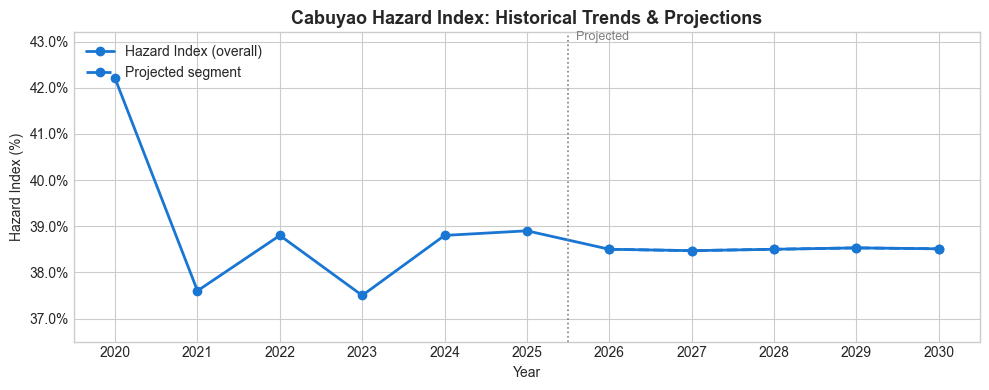

In [16]:
plot_cabuyao_hazard_fixed_pct()

Evaluation year: 2025
Number of barangays with valid sequences: 18
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step

=== 2025 Hazard Index Evaluation (per barangay) ===
MAE (|pred - actual|, in index points): 0.202
Mean Bias Error (pred - actual, in index points): 0.199
Interpretation: Positive bias => model tends to OVERestimate hazard in 2025.


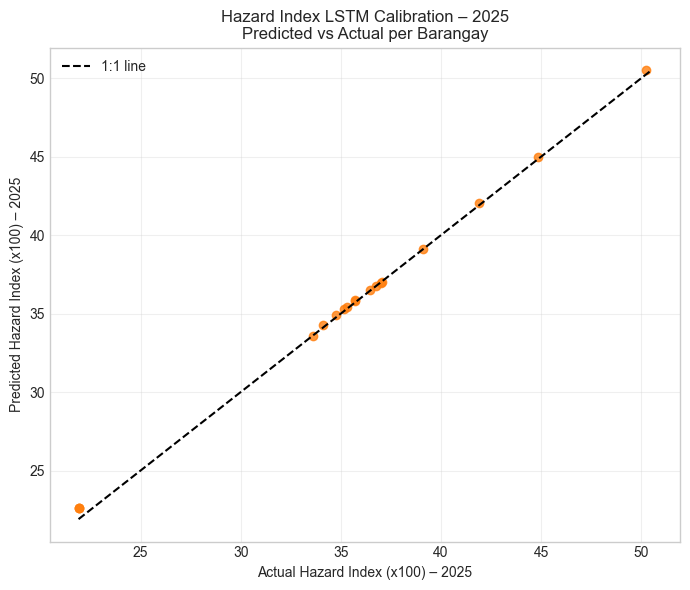

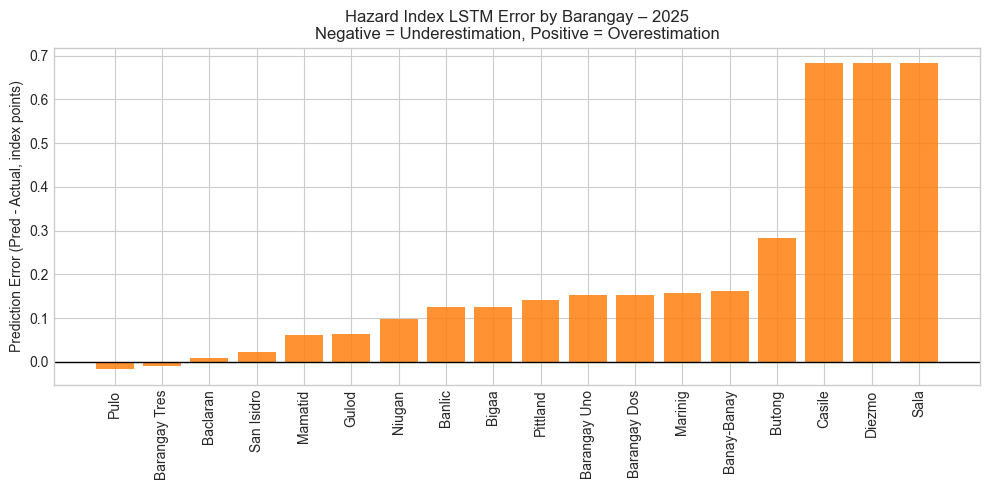

In [19]:
# ============================================================
# Evaluation: 2025 Hazard Index vs LSTM Projection (per barangay)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Prepare 2025 evaluation data
# ------------------------------------------------------------
# Assumptions:
# - `merged_sorted` has columns: ['year', 'date', 'barangay', FEATURE_COLS..., 'y_scaled', 'hazard_index', 'hazard_index_100']
# - `scaled_feat_cols` is the list of feature columns used for LSTM input (e.g. 'rainfall_scaled', ...)
# - `SEQ_LENGTH`, `BARANGAYS`, `target_scaler`, and `model` are already defined from previous cells.

EVAL_YEAR = 2025

# Restrict to data up to the evaluation year
df_eval = merged_sorted.copy()
df_eval = df_eval.sort_values(['barangay', 'date'])

X_eval_list = []
y_true_scaled_list = []
brgy_list = []
date_list = []

for brgy in BARANGAYS:
    brgy_df = df_eval[df_eval['barangay'] == brgy].sort_values('date')

    # rows in the evaluation year
    brgy_2025 = brgy_df[brgy_df['year'] == EVAL_YEAR]
    if brgy_2025.empty:
        continue

    # index of the last available record in 2025 for this barangay
    last_idx = brgy_2025.index.max()

    # all rows up to and including that record
    hist_df = brgy_df.loc[:last_idx]

    if len(hist_df) < SEQ_LENGTH:
        continue  # not enough history

    window = hist_df[scaled_feat_cols].tail(SEQ_LENGTH).values  # (SEQ_LENGTH, n_features)
    if window.shape[0] != SEQ_LENGTH:
        continue

    # true target (scaled) for that last record
    y_true_scaled = hist_df.loc[last_idx, 'y_scaled']

    X_eval_list.append(window)
    y_true_scaled_list.append(y_true_scaled)
    brgy_list.append(brgy)
    date_list.append(hist_df.loc[last_idx, 'date'])

if not X_eval_list:
    raise ValueError(f"No valid sequences found ending in {EVAL_YEAR}. "
                     f"Check that you have at least SEQ_LENGTH months of data per barangay.")

X_eval = np.stack(X_eval_list, axis=0)               # (n_samples, SEQ_LENGTH, n_features)
y_true_scaled = np.array(y_true_scaled_list)         # scaled hazard_index
barangays_eval = np.array(brgy_list)
dates_eval = np.array(date_list)

print(f"Evaluation year: {EVAL_YEAR}")
print(f"Number of barangays with valid sequences: {len(barangays_eval)}")

# ------------------------------------------------------------
# 2. Run the LSTM model and inverse-transform
# ------------------------------------------------------------
if model is None:
    raise ValueError("Trained LSTM model `model` is not available in this notebook.")

y_pred_scaled = model.predict(X_eval).reshape(-1)

# Inverse-transform from scaled [0,1] back to original hazard_index [0,1]
y_true = target_scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
y_pred = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

# Optionally express as 0–100 scores for readability
y_true_100 = y_true * 100.0
y_pred_100 = y_pred * 100.0

# ------------------------------------------------------------
# 3. Compute error metrics and bias
# ------------------------------------------------------------
errors = y_pred_100 - y_true_100
mae_2025 = np.mean(np.abs(errors))
mbe_2025 = np.mean(errors)  # <0 => underestimation on average

print("\n=== 2025 Hazard Index Evaluation (per barangay) ===")
print(f"MAE (|pred - actual|, in index points): {mae_2025:.3f}")
print(f"Mean Bias Error (pred - actual, in index points): {mbe_2025:.3f}")
if mbe_2025 < 0:
    print("Interpretation: Negative bias => model tends to UNDERestimate hazard in 2025.")
elif mbe_2025 > 0:
    print("Interpretation: Positive bias => model tends to OVERestimate hazard in 2025.")
else:
    print("Interpretation: No average bias (pred ≈ actual).")

# ------------------------------------------------------------
# 4. Visualization: Predicted vs Actual (scatter)
# ------------------------------------------------------------
plt.figure(figsize=(7, 6))
plt.scatter(y_true_100, y_pred_100, c="tab:orange", alpha=0.8)

min_val = min(y_true_100.min(), y_pred_100.min())
max_val = max(y_true_100.max(), y_pred_100.max())
plt.plot([min_val, max_val], [min_val, max_val], "k--", label="1:1 line")

plt.xlabel(f"Actual Hazard Index (x100) – {EVAL_YEAR}")
plt.ylabel(f"Predicted Hazard Index (x100) – {EVAL_YEAR}")
plt.title(f"Hazard Index LSTM Calibration – {EVAL_YEAR}\n"
          "Predicted vs Actual per Barangay")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Visualization: Error per barangay
# ------------------------------------------------------------
order = np.argsort(errors)  # most negative (strong underestimation) first
sorted_bgy = barangays_eval[order]
sorted_err = errors[order]

plt.figure(figsize=(10, 5))
plt.bar(range(len(sorted_bgy)), sorted_err, color="tab:orange", alpha=0.85)
plt.axhline(0, color="black", linewidth=1)

plt.xticks(range(len(sorted_bgy)), sorted_bgy, rotation=90)
plt.ylabel("Prediction Error (Pred - Actual, index points)")
plt.title(f"Hazard Index LSTM Error by Barangay – {EVAL_YEAR}\n"
          "Negative = Underestimation, Positive = Overestimation")
plt.tight_layout()
plt.show()